# QSVT with guppy
The Quantum Singular Value Transformation (QSVT) is a quantum algorithm that uses a sequence of alternating phase shifts and a unitary block-encoding $W$ to apply a polynomial transformation $P(W)$ to the singular values (or eigenvalues) of the matrix encoded inside $W$.In this notebook we show how to use the QSVT implementation on ```guppy-algorithms```.

In [1]:
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import zixy.qubit.pauli as zqp
from typing import no_type_check

from guppylang import guppy
from guppylang.std.builtins import comptime, array, dagger
from guppylang.std.quantum import qubit

from guppyalgos.algorithms.block_encoding.qsvt import QSVT
from guppyalgos.utils import ChebyshevPolynomial, QSPAngleFinder
from guppyalgos.tests.helpers import (
    get_unitary_projected,
    assert_allclose_ignorephase,
    Endianness
)
from guppyalgos.algorithms.block_encoding.lcu import (
    LCU,
    LCUData,
    build_double_cntrl_select,
)
from guppyalgos.algorithms.state_preparation import multiplexor_prep



## Hamiltonian Block Encoding
Let us a consider a 2q Hamiltonian. We will be using the LCU algorithm, so we also need to get the conjugate terms of the operator for the dagger object.

In [2]:
def ham_2q() -> zqp.RealTermSum:
    return zqp.ComplexTermSum.from_str("(0.5, Z0 X1), (0.1j, X0 Z1), (0.3j, X0 X1)")

def ham_2q_conj() -> zqp.RealTermSum:
    return zqp.ComplexTermSum.from_str("(0.5, Z0 X1), (-0.1j, X0 Z1), (-0.3j, X0 X1)")

ham_op = ham_2q()
ham_op_dagger = ham_2q_conj()

Now with the defined operations we can construct the lcu and lcu_dagger guppy functions:

In [3]:
data = LCUData.from_hamiltonian(ham_op)
data_dagger = LCUData.from_hamiltonian(ham_op_dagger)
prepare = multiplexor_prep(data.amplitudes)

select = build_double_cntrl_select(data)
select_dagger = build_double_cntrl_select(data_dagger)

n_prep_qubits = data.n_prep_qubits
n_state_qubits = data.n_state_qubits

@guppy
@no_type_check
def unprepare(prep: array[qubit, n_prep_qubits]) -> None:
    with dagger:
        prepare(prep)

# @guppy
# @no_type_check
# def lcu(
#     prep: array[qubit, n_prep_qubits],
#     state: array[qubit, n_state_qubits],
# ) -> None:
#     LCU(prepare, select, unprepare).compose(prep, state)

# @guppy
# @no_type_check
# def lcu_dagger(
#     prep: array[qubit, n_prep_qubits],
#     state: array[qubit, n_state_qubits],
# ) -> None:
#     LCU(prepare, select_dagger, unprepare).compose(prep, state)


## Target function
We can define a target function and use the qsvt utils to obtain the phases. First we need to approximate our target function using ```ChebyshevPolynomial``` and then call the ```QSPAngleFinder``` to obtain the phases. This QSVT implementation assumes the qsp phase reflection convention.

In [4]:
def target_fun(x):
    """Target function."""
    return np.cos(5 * x) / 2


# Since the function is even, we select an even degree
d_phi = 12
d_cheb = d_phi

target_fun_cheb = ChebyshevPolynomial(target_fun, d_cheb)
qsp_optimizer = QSPAngleFinder(
    d_phi=d_phi, target_polynomial=target_fun_cheb
)

phases = qsp_optimizer.phi.copy()

We can also obtain the exact qsvt operation with scipy to compare the results:

In [5]:
from scipy.linalg import svd
from numpy.typing import NDArray

def scipy_qsvt(
    operator: NDArray[np.complex128], polynomial: Polynomial
) -> NDArray[np.complex128]:
    """Scipy implementation of QSVT.

    Polynomial transform of the singular values, where the SVD
    is performed using scipy.linalg.svd. For even polynomial,
    the right singular vectors are used, and for odd polynomial,
    the left singular vectors are used.

    Args:
    ----
        operator (npt.ndarray): matrix operator
        polynomial (Polynomial): polynomial to be applied to
        the singular values of the matrix

    """
    U, s, Vh = svd(operator, full_matrices=True)

    if (len(polynomial) - 1) % 2 == 0:
        # even polynomial
        # ∑_{k} Poly(s_k)|vk> <vk|
        # ONLY USES RIGHT SINGULAR VECS |vk>!
        qsvt = Vh.conj().T @ np.diag(polynomial(s)) @ Vh

    else:
        # odd polynomial
        # ∑_{k} Poly(s_k)|uk> <vk|
        qsvt = U @ np.diag(polynomial(s)) @ Vh

    return qsvt

In [6]:
poly_cos_np = np.polynomial.chebyshev.cheb2poly(qsp_optimizer.target_polynomial.coeffs)
poly_cos_np = Polynomial(poly_cos_np)

actual_hamiltonian = ham_op.to_sparse_matrix().toarray()
actual_hamiltonian_normalized = actual_hamiltonian / data.l1_norm
scipy_qsvt_matrix = scipy_qsvt(actual_hamiltonian_normalized, poly_cos_np)

## Guppy

The ```qsvt``` guppy function receives the qubit registers, the lcu circuits and the phases. It uses the efficient ```cnx``` that uses ceil((n-3)/2) ancillas, where n is the number of controls, which in this case is the number of state qubits. 
We measure both the prep register and the signal for the postprocessing later. Here is the guppy function:

In [7]:
@guppy
def qsvt_circ(
    prep_qreg: array[qubit, n_prep_qubits],
    signal_qreg: array[qubit, 1],
    select_qreg: array[qubit, n_state_qubits],
) -> None:
    QSVT(LCU(prepare, select, unprepare), 
         LCU(prepare, select_dagger, unprepare), 
         comptime(phases)).compose(signal_qreg[0], prep_qreg, select_qreg)


We now can obtain the projected unitary to compare it with the expected transformed hamiltonian.

In [8]:
post_selection = {
    "prep_qreg": [False for _ in range(n_prep_qubits)],
    "signal": [False],
}

guppy_h = get_unitary_projected(
    qsvt_circ, n_state_qubits, post_selection, endianness=Endianness.LITTLE
)

guppy_h

array([[-2.28558195e-02-8.05611451e-16j, -9.39450065e-16+1.38472763e-01j,
         4.78951805e-16+6.24909910e-17j,  8.32638241e-17+1.01321124e-15j],
       [ 6.14862169e-16-1.38472763e-01j, -2.28558195e-02-3.18489362e-16j,
        -7.63416961e-17-8.39789194e-16j,  9.50798902e-16+3.53918753e-16j],
       [-1.21446068e-15-4.84998890e-17j, -1.52657388e-16-1.29076584e-15j,
        -2.28558195e-02-5.68289542e-16j,  6.23341180e-16+1.38472763e-01j],
       [ 4.16431797e-17+3.74867695e-16j, -1.00629849e-15+4.78857202e-16j,
         5.12716456e-17-1.38472763e-01j, -2.28558195e-02+6.68233088e-16j]])

In [9]:
scipy_qsvt_matrix

array([[2.28556101e-02+0.00000000e+00j, 0.00000000e+00-1.38473205e-01j,
        0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j],
       [0.00000000e+00+1.38473205e-01j, 2.28556101e-02+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j],
       [0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j,
        2.28556101e-02-3.08148791e-33j, 1.33187413e-17-1.38473205e-01j],
       [0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j,
        1.33187413e-17+1.38473205e-01j, 2.28556101e-02+0.00000000e+00j]])

In [10]:
assert_allclose_ignorephase(guppy_h, scipy_qsvt_matrix, threshold=1e-3)

We can plot the unitaries:

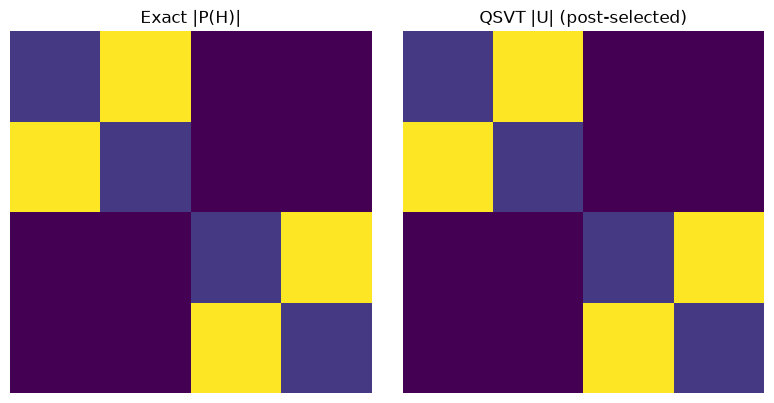

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(np.abs(scipy_qsvt_matrix), cmap='viridis')
axes[0].set_title('Exact |P(H)|')
axes[0].axis('off')

axes[1].imshow(np.abs(guppy_h), cmap='viridis')
axes[1].set_title('QSVT |U| (post-selected)')
axes[1].axis('off')

plt.tight_layout()
plt.show()